# 주제 : 오늘 밤 유럽 축구, 어디가 이길까? 데이터로 분석하고 내기를 이겨보자!

## 데이터 소개
- 이번 주제는 European Soccer Database 데이터셋을 사용합니다.

- 다음 1개의 sqlite 데이터베이스를 사용합니다.
database.sqlite

- 데이터 베이스 내 총 7개의 Table을 사용합니다.   
Country: 국가 정보   
League: 리그 정보     
Match: 경기 정보 (주 데이터셋)   
Player: 플레이어 정보   
Player_Attributes: 플레이어의 특성   
Team: 팀 정보   
Team_Attributes: 팀의 특성

데이터 출처: https://www.kaggle.com/hugomathien/soccer

## 최종 목표
- SQL 데이터셋에서 테이블을 읽어들이는 방법 이해
- 여러개의 테이블을 통합하는 방법 이해
- 수 많은 데이터로부터 관심있는 데이터를 식별
- 학습된 모델로부터 인사이트 습득 방법 이해

출제자 : 신제용 강사

## Step 0. 데이터베이스와 SQL
- 데이터베이스란
- SQL과 Query

## Step 1. 데이터셋 준비하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 문제 1. Colab Notebook에 Kaggle API 세팅하기

In [2]:
import os
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기

In [3]:
os.environ['KAGGLE_USERNAME'] = 'fastcampuskim'
os.environ['KAGGLE_KEY'] = 'c939a1e37f5ca93b6406a66fc8bb08e5'

### 문제 2. 데이터 다운로드 및 압축 해제하기

In [4]:
!kaggle datasets download -d hugomathien/soccer
!unzip '*.zip'

soccer.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  soccer.zip
replace database.sqlite? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: database.sqlite         


### 문제 3. sqlite3와 Pandas로 sqlite 데이터베이스 읽어들이기

In [5]:
import sqlite3

In [6]:
# sqlite3.connect()와 pd.read_sql_query()로 csv파일 읽어들이기
conn = sqlite3.connect('database.sqlite')
df_country = pd.read_sql_query('SELECT * from Country', conn)
df_league = pd.read_sql_query('SELECT * from League', conn)
df_match = pd.read_sql_query('SELECT * from Match', conn)
df_player = pd.read_sql_query('SELECT * from Player', conn)
df_player_att = pd.read_sql_query('SELECT * from Player_Attributes', conn)
df_team = pd.read_sql_query('SELECT * from Team', conn)
df_team_att = pd.read_sql_query('SELECT * from Team_Attributes', conn)

##Step 2. EDA 및 데이터 기초 통계 분석

### 문제 4. 각 데이터프레임의 구조 파악하기

In [7]:
display(df_country.head())
display(df_country.info())

,id,name
0,1,Belgium
1,1729,England
2,4769,France
3,7809,Germany
4,10257,Italy


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      11 non-null     int64 
 1   name    11 non-null     object
dtypes: int64(1), object(1)
memory usage: 304.0+ bytes


None

In [8]:
display(df_league.head())
display(df_league.info())

,id,country_id,name
0,1,1,Belgium Jupiler League
1,1729,1729,England Premier League
2,4769,4769,France Ligue 1
3,7809,7809,Germany 1. Bundesliga
4,10257,10257,Italy Serie A


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          11 non-null     int64 
 1   country_id  11 non-null     int64 
 2   name        11 non-null     object
dtypes: int64(2), object(1)
memory usage: 392.0+ bytes


None

In [9]:
df_league['id'].unique() 

array([    1,  1729,  4769,  7809, 10257, 13274, 15722, 17642, 19694,
       21518, 24558])

In [10]:
df_league['country_id'].unique() # id랑 country_id랑 동일함

array([    1,  1729,  4769,  7809, 10257, 13274, 15722, 17642, 19694,
       21518, 24558])

In [11]:
df_match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Columns: 115 entries, id to BSA
dtypes: float64(96), int64(9), object(10)
memory usage: 22.8+ MB


In [12]:
df_match.drop(df_match.columns[-38:], axis=1, inplace=True) # 총 변수 115개 -> 77개 (38개 제거)

In [13]:
df_player.head()

,id,player_api_id,player_name,player_fifa_api_id,birthday,height,weight
0,1,505942,Aaron Appindangoye,218353,1992-02-29 00:00:00,182.88,187
1,2,155782,Aaron Cresswell,189615,1989-12-15 00:00:00,170.18,146
2,3,162549,Aaron Doran,186170,1991-05-13 00:00:00,170.18,163
3,4,30572,Aaron Galindo,140161,1982-05-08 00:00:00,182.88,198
4,5,23780,Aaron Hughes,17725,1979-11-08 00:00:00,182.88,154


In [14]:
df_player_att.head() # 선수 별 점수

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [15]:
df_team.head()

,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673.0,KRC Genk,GEN
1,2,9993,675.0,Beerschot AC,BAC
2,3,10000,15005.0,SV Zulte-Waregem,ZUL
3,4,9994,2007.0,Sporting Lokeren,LOK
4,5,9984,1750.0,KSV Cercle Brugge,CEB


In [16]:
df_team_att.head()

,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,...,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,1,434,9930,2010-02-22 00:00:00,60,Balanced,NaN,Little,50,Mixed,...,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
1,2,434,9930,2014-09-19 00:00:00,52,Balanced,48.0,Normal,56,Mixed,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
2,3,434,9930,2015-09-10 00:00:00,47,Balanced,41.0,Normal,54,Mixed,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
3,4,77,8485,2010-02-22 00:00:00,70,Fast,NaN,Little,70,Long,...,70,Lots,Organised,60,Medium,70,Double,70,Wide,Cover
4,5,77,8485,2011-02-22 00:00:00,47,Balanced,NaN,Little,52,Mixed,...,52,Normal,Organised,47,Medium,47,Press,52,Normal,Cover


### 문제 5. 데이터프레임간의 관계 파악하기

In [17]:
# 데이터프레임 간 중복되는 Column이 있는지 확인하고 유용한 Column 식별하기
# Hint) unique()로 값을 비교하거나, map() 등을 활용하여 Column 관계를 확인

df_player_att['player_api_id'].value_counts()

41269     56
210278    56
42116     55
26472     54
179795    53
          ..
33688      2
470720     2
37366      2
9144       2
240561     2
Name: player_api_id, Length: 11060, dtype: int64

In [18]:
# 결측치 제거
df_match['home_player_1'].dropna().apply(int).map(df_player_att.groupby('player_api_id').mean()['overall_rating']).isna().sum()

0

In [19]:
df_team_att['team_api_id'].value_counts()

8588      6
8640      6
9864      6
8661      6
8456      6
         ..
8262      1
6351      1
8242      1
274581    1
6631      1
Name: team_api_id, Length: 288, dtype: int64

In [20]:
df_match['away_team_api_id']

0         9993
1         9994
2         8635
3         9998
4         9985
         ...  
25974    10191
25975    10199
25976    10179
25977    10243
25978     9931
Name: away_team_api_id, Length: 25979, dtype: int64

In [21]:
df_team_att.groupby('team_api_id').mean()['buildUpPlaySpeed']

team_api_id
1601      47.333333
1773      52.000000
1957      47.166667
2033      49.000000
2182      60.333333
            ...    
10281     52.833333
108893    43.166667
158085    67.000000
208931    56.000000
274581    50.000000
Name: buildUpPlaySpeed, Length: 288, dtype: float64

In [22]:
# away_team_api_id에 team_api_id별로 buildUpPlaySpeed 평균 값 부여 (api_id 기준으로)
df_match['away_team_api_id'].map(df_team_att.groupby('team_api_id').mean()['buildUpPlaySpeed'])[df_match['away_team_api_id'] == 1601]

15722    47.333333
15736    47.333333
15742    47.333333
15764    47.333333
15787    47.333333
           ...    
17566    47.333333
17582    47.333333
17589    47.333333
17606    47.333333
17622    47.333333
Name: away_team_api_id, Length: 120, dtype: float64

In [23]:
# 값이 부여되지 않은 행 개수 파악 
df_match['away_team_api_id'].map(df_team_att.groupby('team_api_id').mean()['buildUpPlaySpeed']).isna().sum()

178

### 문제 6. 선수 특성 사이의 상관성 파악하기

<Axes: >

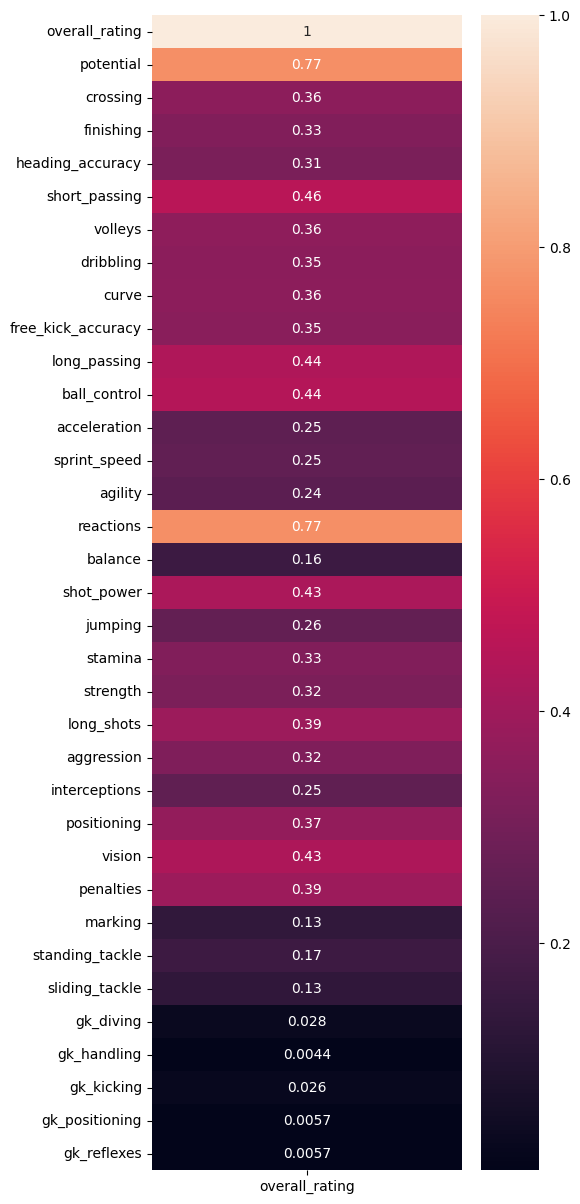

In [24]:
fig = plt.figure(figsize=(5,15))
# 전반적인 평가와 각 특성들 간의 상관성 파악
sns.heatmap(df_player_att.drop(['id', 'player_fifa_api_id', 'player_api_id'], axis=1).corr()[['overall_rating']], annot=True)

### 문제 7. 매치 데이터프레임에 팀 특성 데이터프레임 통합하기

In [25]:
df_team_att.drop('buildUpPlayDribbling', axis=1, inplace=True)

In [26]:
def most(x):
  return x.value_counts().index[0] # 값 별 개수 count 후 가장 개수가 많은 행만 반환

In [27]:
team_map = df_team_att.groupby('team_api_id').aggregate(
    {
       'buildUpPlaySpeed': 'mean',
       'buildUpPlaySpeedClass': most,
       'buildUpPlayDribblingClass': most,
       'buildUpPlayPassing': 'mean',
       'buildUpPlayPassingClass': most,
       'buildUpPlayPositioningClass': most,
       'chanceCreationPassing': 'mean',
       'chanceCreationPassingClass': most,
       'chanceCreationCrossing': 'mean',
       'chanceCreationCrossingClass': most,
       'chanceCreationShooting': 'mean',
       'chanceCreationShootingClass': most,
       'chanceCreationPositioningClass': most,
       'defencePressure': 'mean',
       'defencePressureClass': most,
       'defenceAggression': 'mean',
       'defenceAggressionClass': most,
       'defenceTeamWidth': 'mean',
       'defenceTeamWidthClass': most,
       'defenceDefenderLineClass': most
    }
)

In [28]:
team_map.head()
# 팀별 최빈값만 남기고 제거

,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
team_api_id,,,,,,,,,,,,,,,,,,,,
1601,47.333333,Balanced,Little,46.166667,Mixed,Organised,55.500000,Normal,60.333333,Normal,53.5,Normal,Organised,47.166667,Medium,47.333333,Press,49.333333,Normal,Cover
1773,52.000000,Balanced,Little,50.000000,Mixed,Organised,50.000000,Normal,53.000000,Normal,54.0,Normal,Organised,43.000000,Medium,44.000000,Press,50.000000,Normal,Cover
1957,47.166667,Balanced,Little,52.666667,Mixed,Organised,50.833333,Normal,36.333333,Normal,67.0,Lots,Organised,49.333333,Medium,56.333333,Press,53.666667,Normal,Cover
2033,49.000000,Balanced,Little,48.400000,Mixed,Organised,51.800000,Normal,44.200000,Normal,48.2,Normal,Free Form,42.200000,Medium,33.800000,Contain,45.400000,Normal,Cover
2182,60.333333,Balanced,Little,49.000000,Mixed,Organised,56.666667,Normal,57.333333,Normal,68.0,Lots,Organised,51.666667,Medium,48.500000,Press,54.500000,Normal,Cover


In [29]:
df = df_match[['home_team_goal', 'away_team_goal']].copy()

In [30]:
for team in ['home_','away_']:
  team_map.index.name = team + 'team_api_id'
  for col in team_map.columns:
    df[team + col] = df_match[team_map.index.name].map(team_map[col])

In [31]:
df.dropna(inplace=True)

In [32]:
df.head()

,home_team_goal,away_team_goal,home_buildUpPlaySpeed,home_buildUpPlaySpeedClass,home_buildUpPlayDribblingClass,home_buildUpPlayPassing,home_buildUpPlayPassingClass,home_buildUpPlayPositioningClass,home_chanceCreationPassing,home_chanceCreationPassingClass,...,away_chanceCreationShooting,away_chanceCreationShootingClass,away_chanceCreationPositioningClass,away_defencePressure,away_defencePressureClass,away_defenceAggression,away_defenceAggressionClass,away_defenceTeamWidth,away_defenceTeamWidthClass,away_defenceDefenderLineClass
0,1,1,56.333333,Balanced,Little,44.333333,Mixed,Organised,55.666667,Normal,...,53.750000,Normal,Organised,48.250000,Medium,49.000000,Press,58.750000,Wide,Cover
1,0,0,55.500000,Balanced,Little,52.666667,Mixed,Organised,50.000000,Normal,...,54.333333,Normal,Organised,48.833333,Medium,55.166667,Press,55.500000,Normal,Cover
2,0,3,53.666667,Balanced,Little,44.166667,Mixed,Organised,59.000000,Normal,...,51.333333,Normal,Organised,59.666667,Medium,47.666667,Press,63.833333,Normal,Cover
3,5,0,54.166667,Balanced,Little,46.333333,Mixed,Organised,44.500000,Normal,...,46.000000,Normal,Organised,46.000000,Medium,45.000000,Press,47.000000,Normal,Cover
5,1,1,56.666667,Balanced,Little,47.333333,Mixed,Organised,47.500000,Normal,...,47.666667,Normal,Organised,53.666667,Medium,53.833333,Press,54.666667,Normal,Cover


### 문제 8. 홈과 어웨이의 골 수를 승-무-패 범주로 변환하기

In [33]:
# 0 : 홈팀 승, 1: 무승부, 2:어웨이팀 승
df['matchResult'] = df[['home_team_goal','away_team_goal']].aggregate(lambda x:0 if x[0] > x[1] else 1 if x[0] == x[1] else 2, axis=1)

In [34]:
df.drop(['home_team_goal', 'away_team_goal'], axis=1, inplace=True)

## Step 3. 모델 학습을 위한 데이터 전처리

### 문제 9. get_dummies()를 이용하여 범주형 데이터 전처리하기

In [35]:
df.columns

Index(['home_buildUpPlaySpeed', 'home_buildUpPlaySpeedClass',
       'home_buildUpPlayDribblingClass', 'home_buildUpPlayPassing',
       'home_buildUpPlayPassingClass', 'home_buildUpPlayPositioningClass',
       'home_chanceCreationPassing', 'home_chanceCreationPassingClass',
       'home_chanceCreationCrossing', 'home_chanceCreationCrossingClass',
       'home_chanceCreationShooting', 'home_chanceCreationShootingClass',
       'home_chanceCreationPositioningClass', 'home_defencePressure',
       'home_defencePressureClass', 'home_defenceAggression',
       'home_defenceAggressionClass', 'home_defenceTeamWidth',
       'home_defenceTeamWidthClass', 'home_defenceDefenderLineClass',
       'away_buildUpPlaySpeed', 'away_buildUpPlaySpeedClass',
       'away_buildUpPlayDribblingClass', 'away_buildUpPlayPassing',
       'away_buildUpPlayPassingClass', 'away_buildUpPlayPositioningClass',
       'away_chanceCreationPassing', 'away_chanceCreationPassingClass',
       'away_chanceCreationCrossi

In [36]:
# 찾는 문자가 존재한다면 해당 위치의 index 반환, 존재하지 않는 경우 -1 반환
col_cats = list(filter(lambda s: s.find('Class') >= 0, df.columns))
df_cats = pd.get_dummies(df[col_cats], drop_first=True)
df_cats

,home_buildUpPlaySpeedClass_Fast,home_buildUpPlaySpeedClass_Slow,home_buildUpPlayDribblingClass_Normal,home_buildUpPlayPassingClass_Mixed,home_buildUpPlayPassingClass_Short,home_buildUpPlayPositioningClass_Organised,home_chanceCreationPassingClass_Risky,home_chanceCreationPassingClass_Safe,home_chanceCreationCrossingClass_Lots,home_chanceCreationCrossingClass_Normal,...,away_chanceCreationCrossingClass_Normal,away_chanceCreationShootingClass_Normal,away_chanceCreationPositioningClass_Organised,away_defencePressureClass_High,away_defencePressureClass_Medium,away_defenceAggressionClass_Double,away_defenceAggressionClass_Press,away_defenceTeamWidthClass_Normal,away_defenceTeamWidthClass_Wide,away_defenceDefenderLineClass_Offside Trap
0,0,0,0,1,0,1,0,0,0,1,...,1,1,1,0,1,0,1,0,1,0
1,0,0,0,1,0,1,0,0,0,1,...,1,1,1,0,1,0,1,1,0,0
2,0,0,0,1,0,1,0,0,0,1,...,1,1,1,0,1,0,1,1,0,0
3,0,0,0,1,0,1,0,0,0,1,...,0,1,1,0,1,0,1,1,0,0
5,0,0,0,1,0,1,0,0,0,1,...,1,1,1,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25972,0,0,0,1,0,1,0,0,0,1,...,1,1,1,0,1,0,1,1,0,0
25974,0,0,0,1,0,1,0,0,0,1,...,1,1,1,0,1,0,1,1,0,0
25975,0,0,0,1,0,1,0,0,0,1,...,1,1,1,0,1,0,1,1,0,0
25976,0,0,0,1,0,1,0,0,0,1,...,1,1,1,0,1,0,1,1,0,0


### 문제 10. StandardScaler를 이용해 수치형 데이터 표준화하기

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
X_num = df.drop(['matchResult'] + col_cats, axis=1) # target값 & 범주형 변수 제거
scaler = StandardScaler()
scaler.fit(X_num)
X_scaled = scaler.transform(X_num)
X_scaled = pd.DataFrame(data=X_scaled, index=X_num.index, columns=X_num.columns)

X_cat = df_cats
X = pd.concat([X_scaled, X_cat], axis=1)
y = df['matchResult']

### 문제 11. 학습데이터와 테스트데이터 분리하기

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

## Step 4. Classification 모델 학습하기

### 문제 12. Logistic Regression 모델 생성/학습하기

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
model_lr = LogisticRegression(max_iter=10000)
model_lr.fit(X_train,y_train)

LogisticRegression(max_iter=10000)

### 문제 13. 모델 학습 결과 평가하기

In [43]:
from sklearn.metrics import classification_report

In [44]:
pred = model_lr.predict(X_test)
print(classification_report(y_test,pred)) 
# Precision : 예측값 기준 정답인 예측값의 비율
# Recall : 실제값 기준 정답인 예측값의 비율
# support : 각 라벨의 실제 샘플 개수
# 1 : 무승부인 경우 & 2 : 어웨이팀 승 -> 잘 예측하지 못함
# 정확도 : 0.48

              precision    recall  f1-score   support

           0       0.49      0.87      0.63      3484
           1       0.24      0.00      0.00      1972
           2       0.44      0.31      0.36      2233

    accuracy                           0.48      7689
   macro avg       0.39      0.39      0.33      7689
weighted avg       0.41      0.48      0.39      7689



In [45]:
print(sum((y_test == 0)) / len(y_test))
print(sum((y_test == 1)) / len(y_test))
print(sum((y_test == 2)) / len(y_test))

0.4531148393809338
0.2564702822213552
0.290414878397711


### 문제 14. XGBoost 모델 생성/학습하기

In [46]:
from xgboost import XGBClassifier

In [47]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              objective='multi:softprob', predictor=None, ...)

###문제 15. 모델 학습 결과 평가하기

In [48]:
pred = model_xgb.predict(X_test)
print(classification_report(y_test,pred))
# 정확도 = 0.48

              precision    recall  f1-score   support

           0       0.54      0.72      0.61      3484
           1       0.29      0.15      0.20      1972
           2       0.45      0.40      0.42      2233

    accuracy                           0.48      7689
   macro avg       0.42      0.42      0.41      7689
weighted avg       0.45      0.48      0.45      7689



## Step5 모델 학습 결과 심화 분석하기

### 문제 16. Logistic Regression 모델 계수로 상관성 파악하기

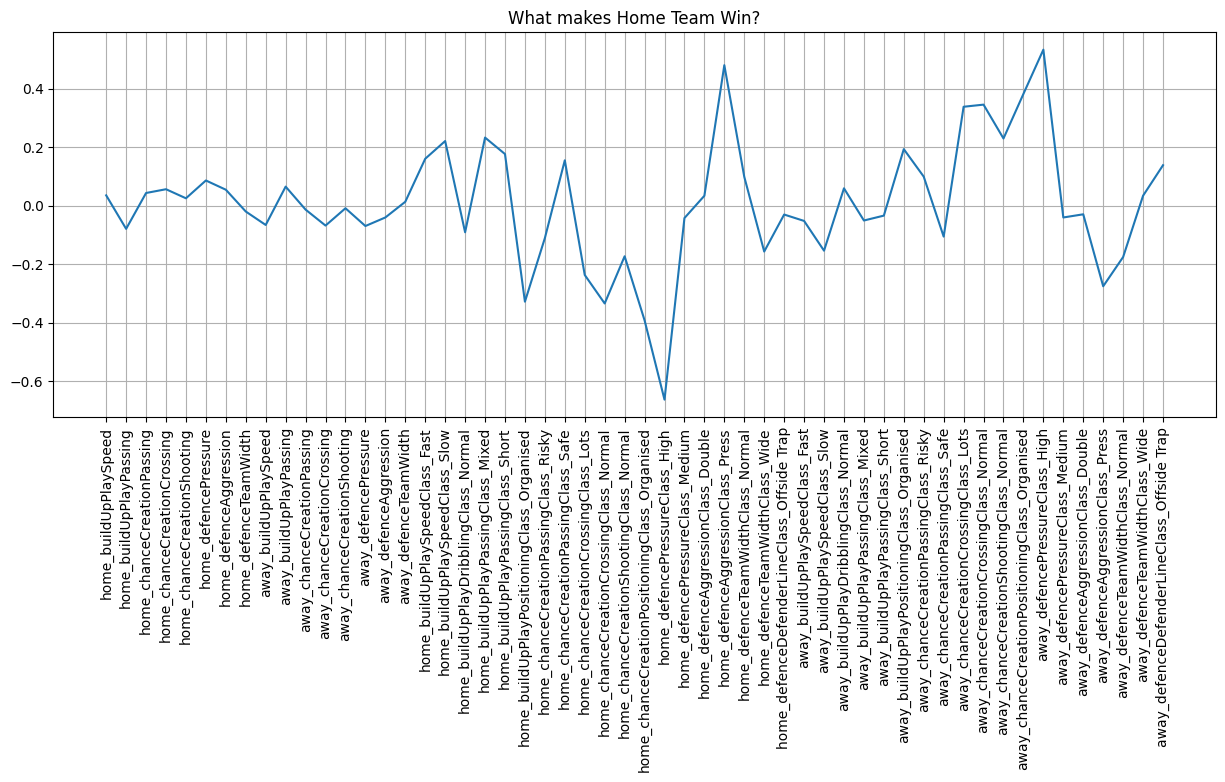

In [49]:
fig = plt.figure(figsize=(15, 5))
plt.plot(X.columns, model_lr.coef_[0])
plt.xticks(rotation=90)
plt.title('What makes Home Team Win?')
plt.grid()
plt.show()

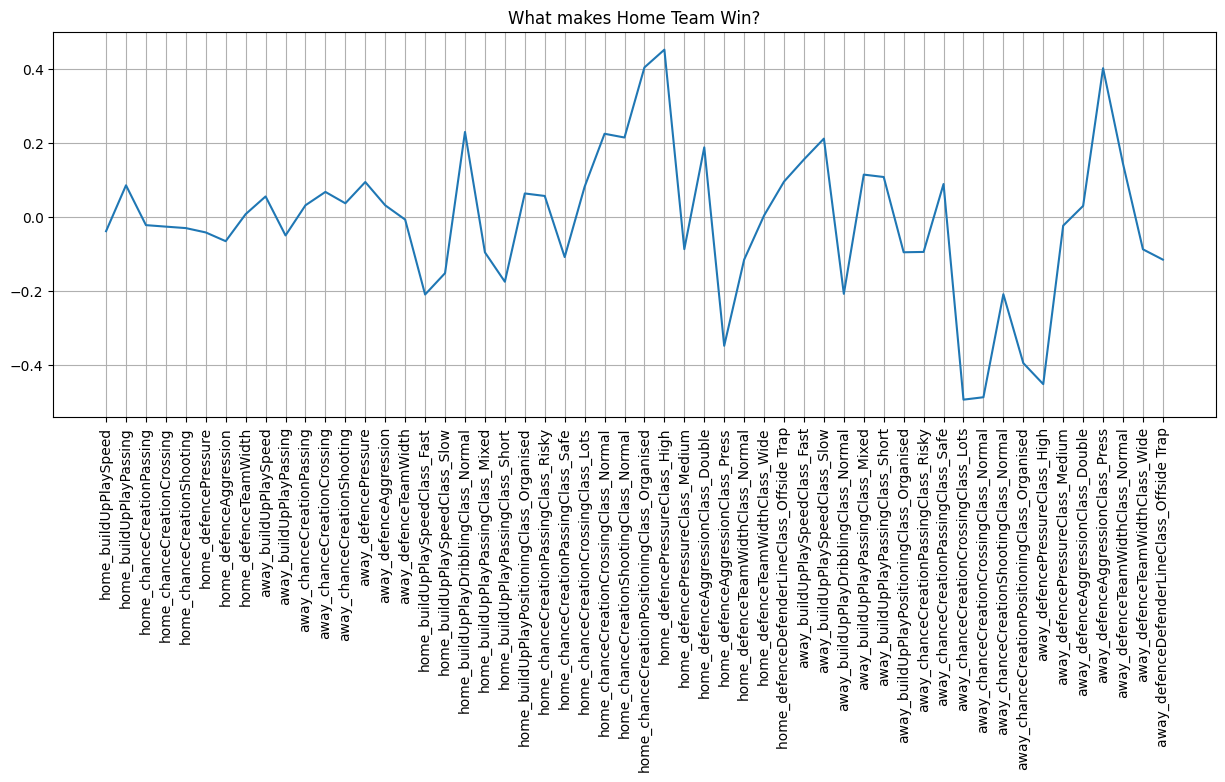

In [50]:
fig = plt.figure(figsize=(15, 5))
plt.plot(X.columns, model_lr.coef_[2])
plt.xticks(rotation=90)
plt.title('What makes Home Team Win?')
plt.grid()
plt.show()

### 문제 17. XGBoost 모델로 특징의 중요도 확인하기

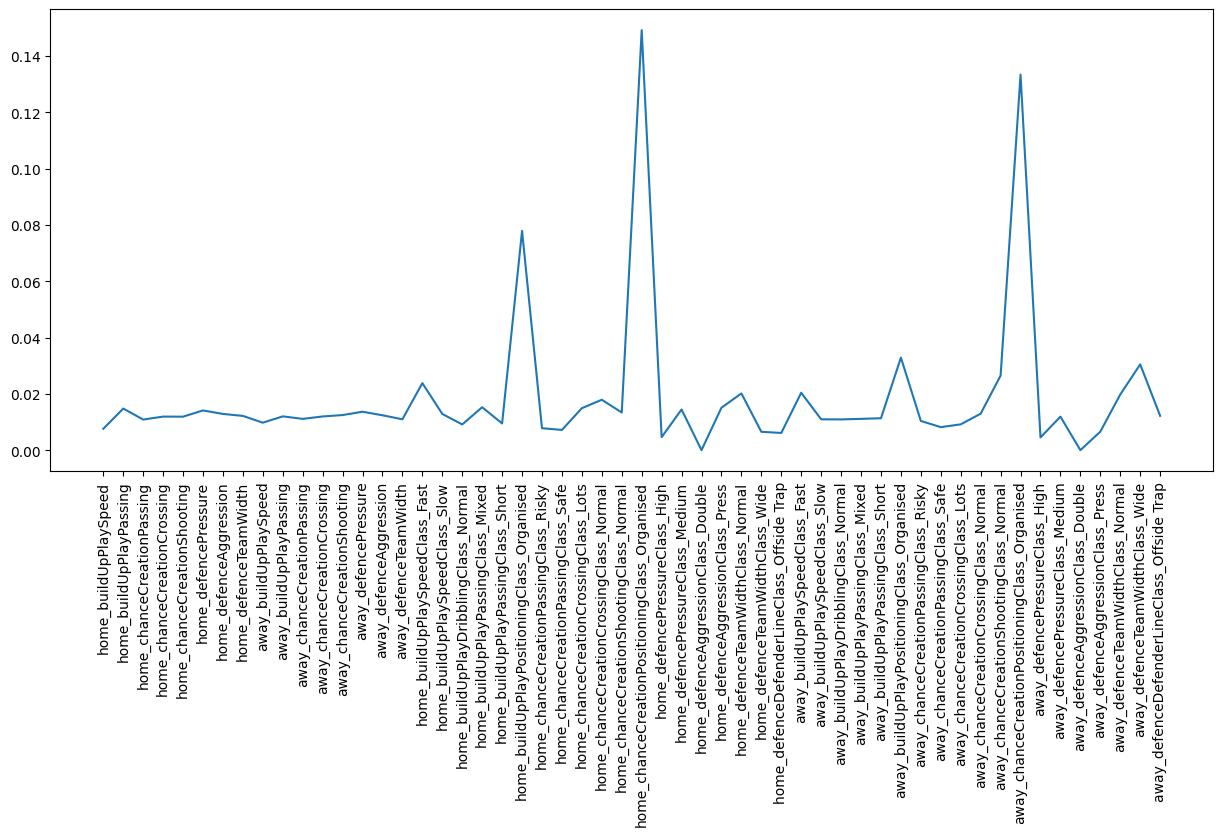

In [51]:
fig = plt.figure(figsize=(15, 6))
plt.plot(X.columns, model_xgb.feature_importances_)
plt.xticks(rotation=90)
plt.show()

## Step6 모델 성능 개선하기

### 문제 18. 매치 데이터프레임에 선수 특성 데이터프레임 통합하기

In [79]:
df = df_match[['home_team_goal','away_team_goal']].copy()
df.shape

(25979, 2)

In [80]:
for team in ['home_', 'away_']:
  team_map.index.name = team + 'team_api_id'
  for col in team_map.columns:
    df[team + col] = df_match[team_map.index.name].map(team_map[col])

In [81]:
df.shape # 42개

(25979, 42)

In [82]:
df.head(3)

,home_team_goal,away_team_goal,home_buildUpPlaySpeed,home_buildUpPlaySpeedClass,home_buildUpPlayDribblingClass,home_buildUpPlayPassing,home_buildUpPlayPassingClass,home_buildUpPlayPositioningClass,home_chanceCreationPassing,home_chanceCreationPassingClass,...,away_chanceCreationShooting,away_chanceCreationShootingClass,away_chanceCreationPositioningClass,away_defencePressure,away_defencePressureClass,away_defenceAggression,away_defenceAggressionClass,away_defenceTeamWidth,away_defenceTeamWidthClass,away_defenceDefenderLineClass
0,1,1,56.333333,Balanced,Little,44.333333,Mixed,Organised,55.666667,Normal,...,53.750000,Normal,Organised,48.250000,Medium,49.000000,Press,58.750000,Wide,Cover
1,0,0,55.500000,Balanced,Little,52.666667,Mixed,Organised,50.000000,Normal,...,54.333333,Normal,Organised,48.833333,Medium,55.166667,Press,55.500000,Normal,Cover
2,0,3,53.666667,Balanced,Little,44.166667,Mixed,Organised,59.000000,Normal,...,51.333333,Normal,Organised,59.666667,Medium,47.666667,Press,63.833333,Normal,Cover


In [83]:
player_map = df_player_att.groupby('player_api_id').mean()['overall_rating']
player_map

player_api_id
2625      60.142857
2752      69.380952
2768      69.285714
2770      71.133333
2790      70.200000
            ...    
744907    51.909091
746419    59.000000
748432    58.000000
750435    56.444444
750584    58.000000
Name: overall_rating, Length: 11060, dtype: float64

In [85]:
for col in (s + str(idx) for s in ['home_player_', 'away_player_'] for idx in range(1, 12)):
  df[col + '_rating']= df_match[col].map(player_map)
df.dropna(inplace=True)
# 플레이어별 평균 평가 컬럼 추가 & 결측치 존재하는 행 제거
df.shape # 64개

(21246, 64)

In [87]:
# 0 : 홈팀 승, 1: 무승부, 2:어웨이팀 승
df['matchResult'] = df[['home_team_goal','away_team_goal']].aggregate(lambda x:0 if x[0] > x[1] else 1 if x[0] == x[1] else 2, axis=1)

In [88]:
X_num = df.drop(['matchResult','home_team_goal','away_team_goal'] + col_cats, axis=1)
scaler = StandardScaler()
scaler.fit(X_num)
X_scaled = scaler.transform(X_num)
X_scaled = pd.DataFrame(data=X_scaled, index=X_num.index, columns=X_num.columns)

X_cat = pd.get_dummies(df[col_cats], drop_first=True) # 원핫인코딩
X = pd.concat([X_scaled, X_cat], axis=1)
y = df['matchResult']

In [89]:
X.shape # 범주형변수 인코딩때문에

(21246, 76)

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

### 문제 19. 모델 재학습하여 평가하기

In [91]:
model_lr = LogisticRegression(max_iter=10000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [92]:
pred = model_lr.predict(X_test)
print(classification_report(y_test, pred))
# 정확도 0.53

              precision    recall  f1-score   support

           0       0.56      0.83      0.67      2945
           1       0.33      0.01      0.02      1587
           2       0.48      0.50      0.49      1842

    accuracy                           0.53      6374
   macro avg       0.45      0.45      0.39      6374
weighted avg       0.48      0.53      0.45      6374



In [93]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)
pred = model_xgb.predict(X_test)
print(classification_report(y_test, pred))
# 정확도 0.5

              precision    recall  f1-score   support

           0       0.56      0.75      0.64      2945
           1       0.26      0.12      0.17      1587
           2       0.48      0.44      0.45      1842

    accuracy                           0.50      6374
   macro avg       0.43      0.44      0.42      6374
weighted avg       0.46      0.50      0.47      6374



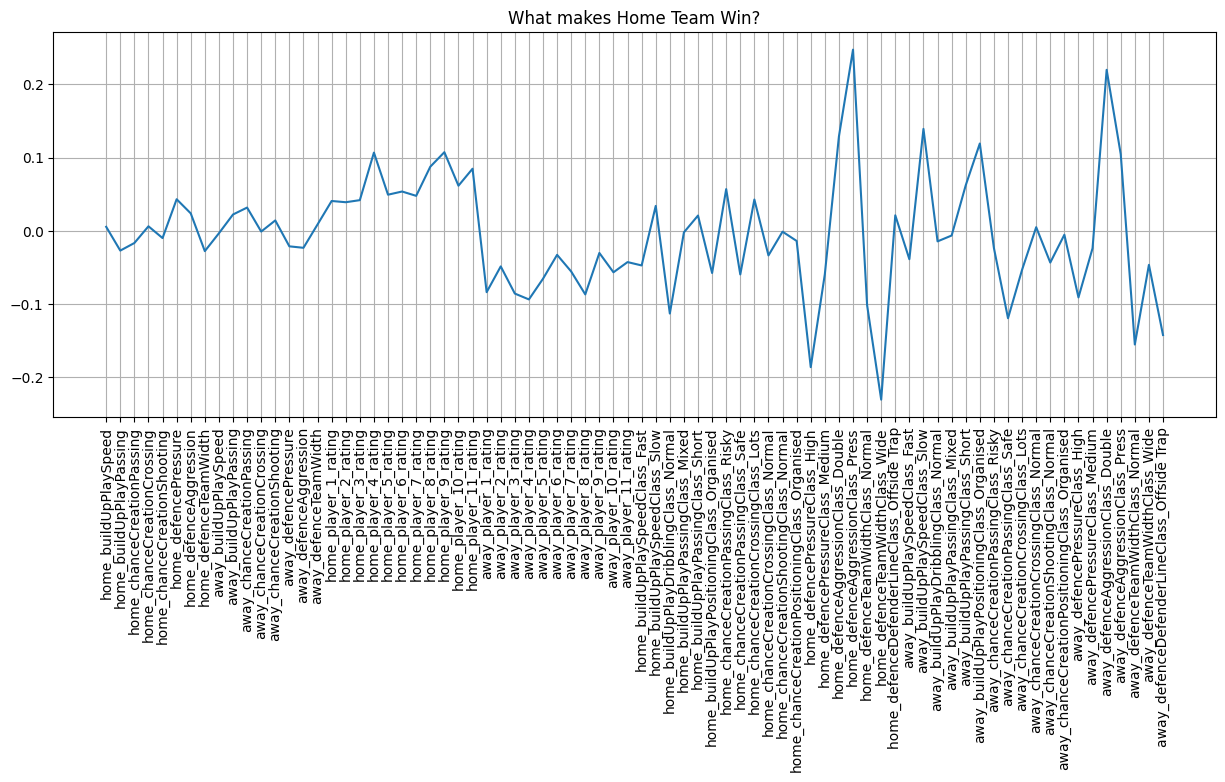

In [94]:
fig = plt.figure(figsize=(15, 5))
plt.plot(X.columns, model_lr.coef_[0])
plt.xticks(rotation=90)
plt.title('What makes Home Team Win?')
plt.grid()
plt.show()

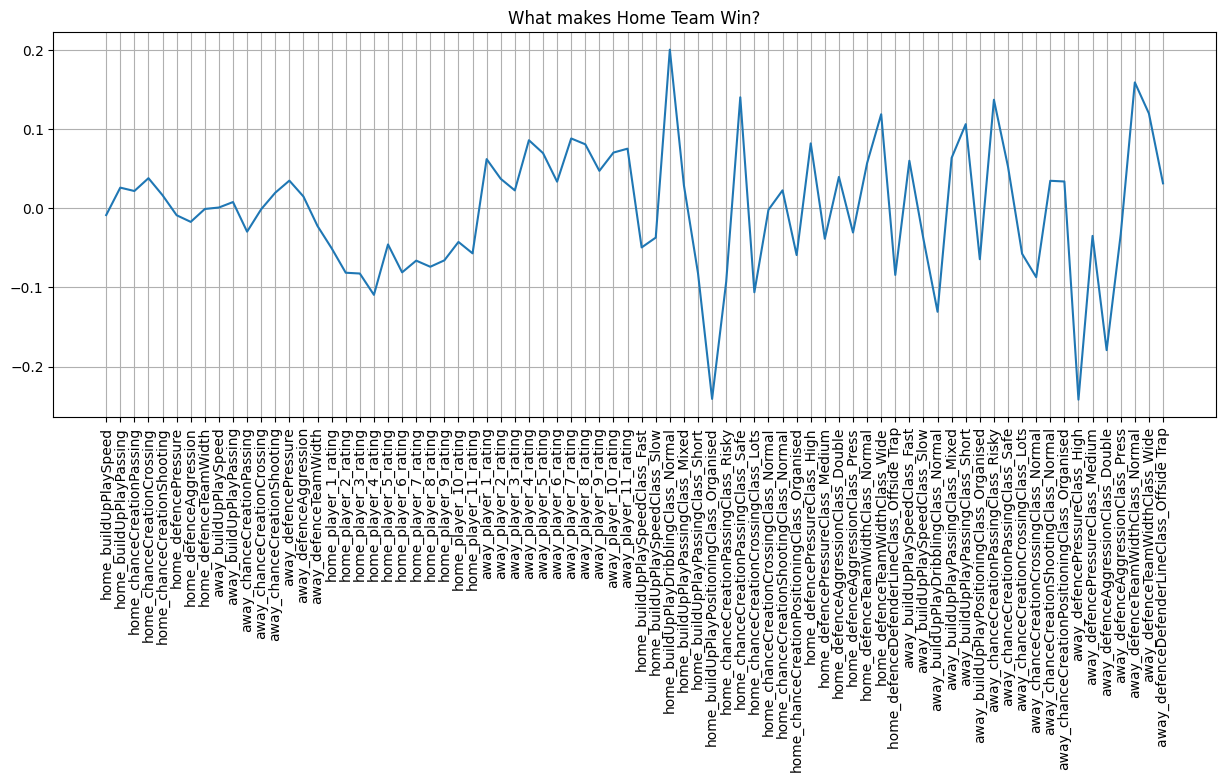

In [95]:
fig = plt.figure(figsize=(15, 5))
plt.plot(X.columns, model_lr.coef_[2])
plt.xticks(rotation=90)
plt.title('What makes Home Team Win?')
plt.grid()
plt.show()

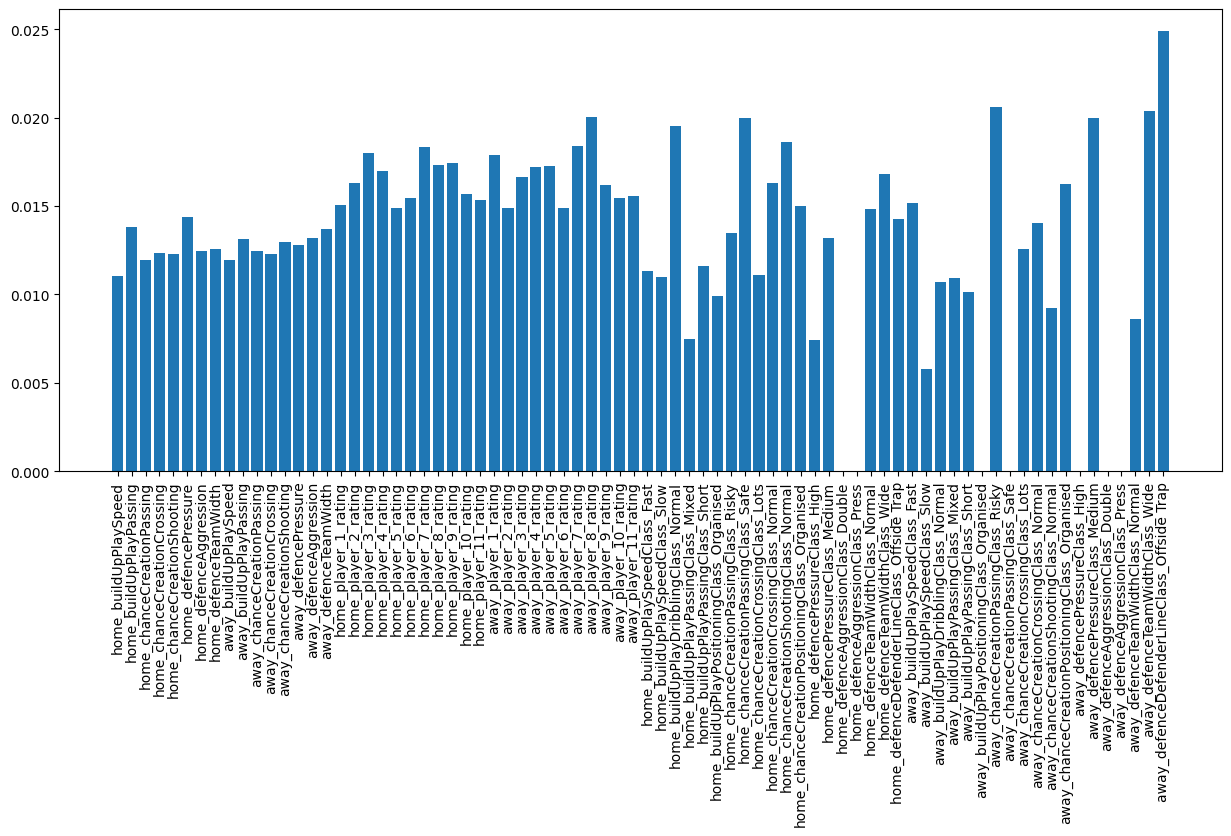

In [96]:
fig = plt.figure(figsize=(15, 6))
plt.bar(X.columns, model_xgb.feature_importances_)
plt.xticks(rotation=90)
plt.show()